# Experimental Notebook For Siamese Network Project

A litttle about the Siamese network and why this project.

A Siamese Neural Network is a special type of neural network designed to determine how similar two inputs are rather than simply classifying them into categories. Instead of predicting labels directly, **a Siamese network learns meaningful feature representations called embeddings**. These embeddings allow the model to compare two images, texts, or signals and determine whether they belong to the same class or identity.

The architecture(see image below) typically consists of two identical subnetworks that share the same weights and parameters. Each branch processes one input independently and transforms it into a feature vector. **The outputs are then compared using a similarity metric such as Euclidean distance or cosine similarity**. During training, the model learns to minimize the distance between similar pairs and maximize the distance between dissimilar pairs.

Siamese networks became especially popular in areas such as:

* facial recognition
* signature verification
* biometric authentication
* image similarity search
* anomaly detection
* one-shot and few-shot learning

One of the biggest strengths of Siamese networks is that they perform well even when limited labeled data is available. Instead of requiring thousands of examples per class, the model learns general similarity patterns, making it highly scalable for real-world verification systems.

This project was motivated by the growing need for intelligent identity verification systems that are secure, scalable, and capable of learning meaningful visual representations rather than memorizing classes. Traditional classification models struggle when new identities are introduced because they often require retraining. A Siamese network solves this problem by learning an embedding space where similar identities cluster together naturally.

In this project, the Siamese architecture is combined with deep convolutional feature extraction to generate embeddings from facial images. These embeddings are then compared against stored customer embeddings using similarity measures such as cosine similarity. The goal is to simulate a real-world AI-powered banking or ATM verification system capable of identifying existing customers while also detecting unknown or unauthorized users.

Beyond identity verification, the project also explores concepts central to modern AI systems, including:

* feature representation learning
* metric learning
* embedding generation
* similarity comparison
* biometric security
* scalable authentication pipelines

The project demonstrates how deep learning can move beyond traditional classification tasks into intelligent decision-making systems that compare, reason about, and validate relationships between data samples.


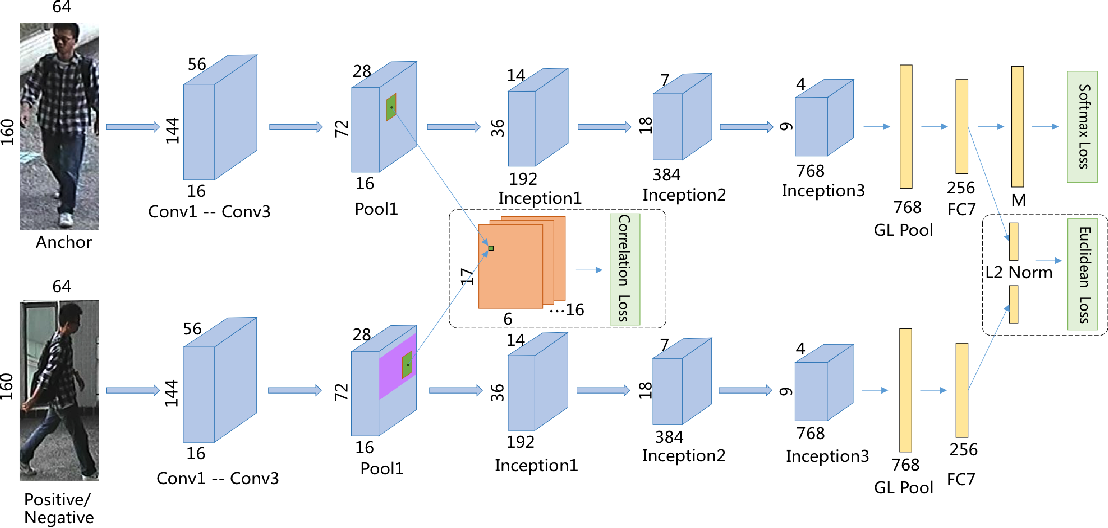

In [1]:
##create a custtom exceptions class for the project
class ProjectException(Exception):
    """
    Base exception for all custom errors in this project.
    Inherits from the built-in Exception so standard error handling works.
    """
    pass

In [2]:
##create a custom logger
import logging
def get_logger():
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    logger = logging.getLogger(__name__)
    return logger

#initialize the logger
logger = get_logger()

In [3]:
from os.path import isdir
import os
import kagglehub
from pathlib import Path

#define the dataset identifier
DATASET_NAME = "jessicali9530/lfw-dataset"
CACHE_DIR = Path.cwd() / "data"/ "siamese_face" #custom cache directory
DATA_DIR = CACHE_DIR / "lfw"

def download_lfw():
    """
    Download LFW dataset from Kagglehub with intelligent caching.
    Returns the path to the root image directory.
    """
    if DATA_DIR.exists():
        print(f"Dataset already exists at {DATA_DIR}")
        return str(DATA_DIR)
    print("Downloading dataset from kagglehub...")
    path = kagglehub.dataset_download(DATASET_NAME)
    print(f"kagglehub cache path: {path}")

    src_dir = None
    for root, dirs, files in os.walk(path):
        if "lfw-deepfunneled" in dirs:
            src_dir = os.path.join(root, "lfw-deepfunneled")
            break
        elif "lfw" in dirs:
            src_dir = os.path.join(root, "lfw")
            break
    if src_dir is None:
        raise ProjectException("could not locate image dir in download dataset")

    #symlink/copy to out custome cache directory
    DATA_DIR.mkdir(exist_ok=True, parents=True)
    #copy the contents (or symlink) to avoid relying on kagglehub's versioned cache
    target = DATA_DIR
    if not any(os.scandir(target)):
        #if data_dir is empty, populate it
        for item in os.listdir(src_dir):
            src_item = os.path.join(src_dir, item)
            dst_item = target/item
            if not dst_item.exists():
                #if not symlink possible, copy
                try:
                    os.symlink(src_item, dst_item)
                    print(f"symlinked {src_item} to {dst_item}")
                except OSError:
                    import shutil
                    if os.path.isdir(src_item):
                        shutil.copytree(src_item, dst_item)
                    else:
                        shutil.copy(src_item, dst_item)
                    print(f"copying {src_item} to {dst_item}")
    print(f"dataset ready at {DATA_DIR}")
    return str(DATA_DIR)

#CALL THE FUNCTION
root_dir = download_lfw()
print("root directory:", root_dir)

c:\Users\LENOVO\Documents\anaconda\envs\siamese\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


kagglehub cache path: C:\Users\LENOVO\.cache\kagglehub\datasets\jessicali9530\lfw-dataset\versions\4
copying C:\Users\LENOVO\.cache\kagglehub\datasets\jessicali9530\lfw-dataset\versions\4\lfw-deepfunneled\lfw-deepfunneled to c:\Users\LENOVO\Desktop\projects\siamese-net\Siamese-Net\notebook\data\siamese_face\lfw\lfw-deepfunneled
dataset ready at c:\Users\LENOVO\Desktop\projects\siamese-net\Siamese-Net\notebook\data\siamese_face\lfw
root directory: c:\Users\LENOVO\Desktop\projects\siamese-net\Siamese-Net\notebook\data\siamese_face\lfw


Exploratory Data Analysis (EDA)

In [4]:
lfw_root  = Path(DATA_DIR)
lfw_root = os.path.join(lfw_root,"lfw-deepfunneled")
print(lfw_root)

c:\Users\LENOVO\Desktop\projects\siamese-net\Siamese-Net\notebook\data\siamese_face\lfw\lfw-deepfunneled


In [5]:
Path(lfw_root)

WindowsPath('c:/Users/LENOVO/Desktop/projects/siamese-net/Siamese-Net/notebook/data/siamese_face/lfw/lfw-deepfunneled')

In [6]:
import matplotlib.pyplot as plt
import random
from PIL import Image
from collections import Counter

#using DATA_DIR from above
lfw_root  = Path(DATA_DIR)
lfw_root = os.path.join(lfw_root,"lfw-deepfunneled")
lfw_root = Path(lfw_root)
print(lfw_root)

#get list of all person directories(each contains images of one identity)
person_dirs = [d for d in lfw_root.iterdir() if d.is_dir()] #gets all the people folders
num_people = len(person_dirs)
print(f"Total number of persons/identities: {num_people}")

#count images per person
image_extensions = {".jpg",".jpeg",".png"}
person_image_counts = {}
total_images = 0

for person_dir in list(person_dirs) if isinstance(person_dirs, list) else person_dirs:
    images = [f for f in person_dir.iterdir() if f.suffix.lower() in image_extensions]
    person_image_counts[person_dir.name] = len(images)
    total_images += len(images)

print(f"Total number of images: {total_images}")
print(f"Images per person statistics:")
counts = list(person_image_counts.values())
print(f"Min: {min(counts)}, Max: {max(counts)}, Avg: {sum(counts)/len(counts):.3f}, Median: {sorted(counts)[len(counts)//2]}")

c:\Users\LENOVO\Desktop\projects\siamese-net\Siamese-Net\notebook\data\siamese_face\lfw\lfw-deepfunneled
Total number of persons/identities: 5749
Total number of images: 13233
Images per person statistics:
Min: 1, Max: 530, Avg: 2.302, Median: 1


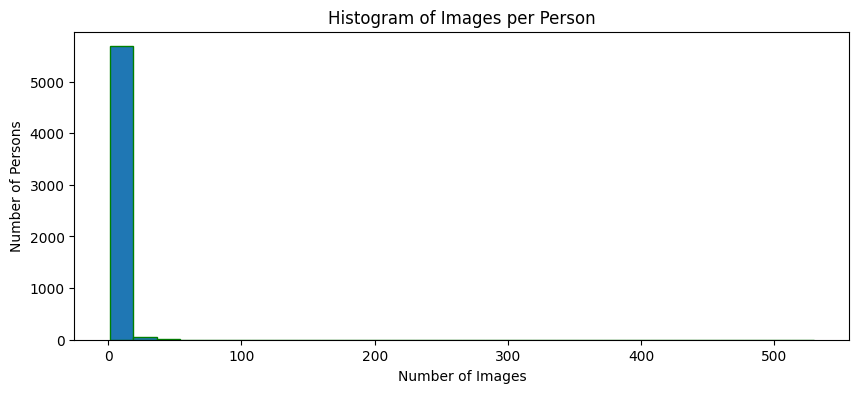

In [7]:
#plot histograms of images per person
plt.figure(figsize=(10,4))
plt.hist(counts, bins=30, edgecolor='green')
plt.title("Histogram of Images per Person")
plt.xlabel("Number of Images")
plt.ylabel("Number of Persons")
plt.show()

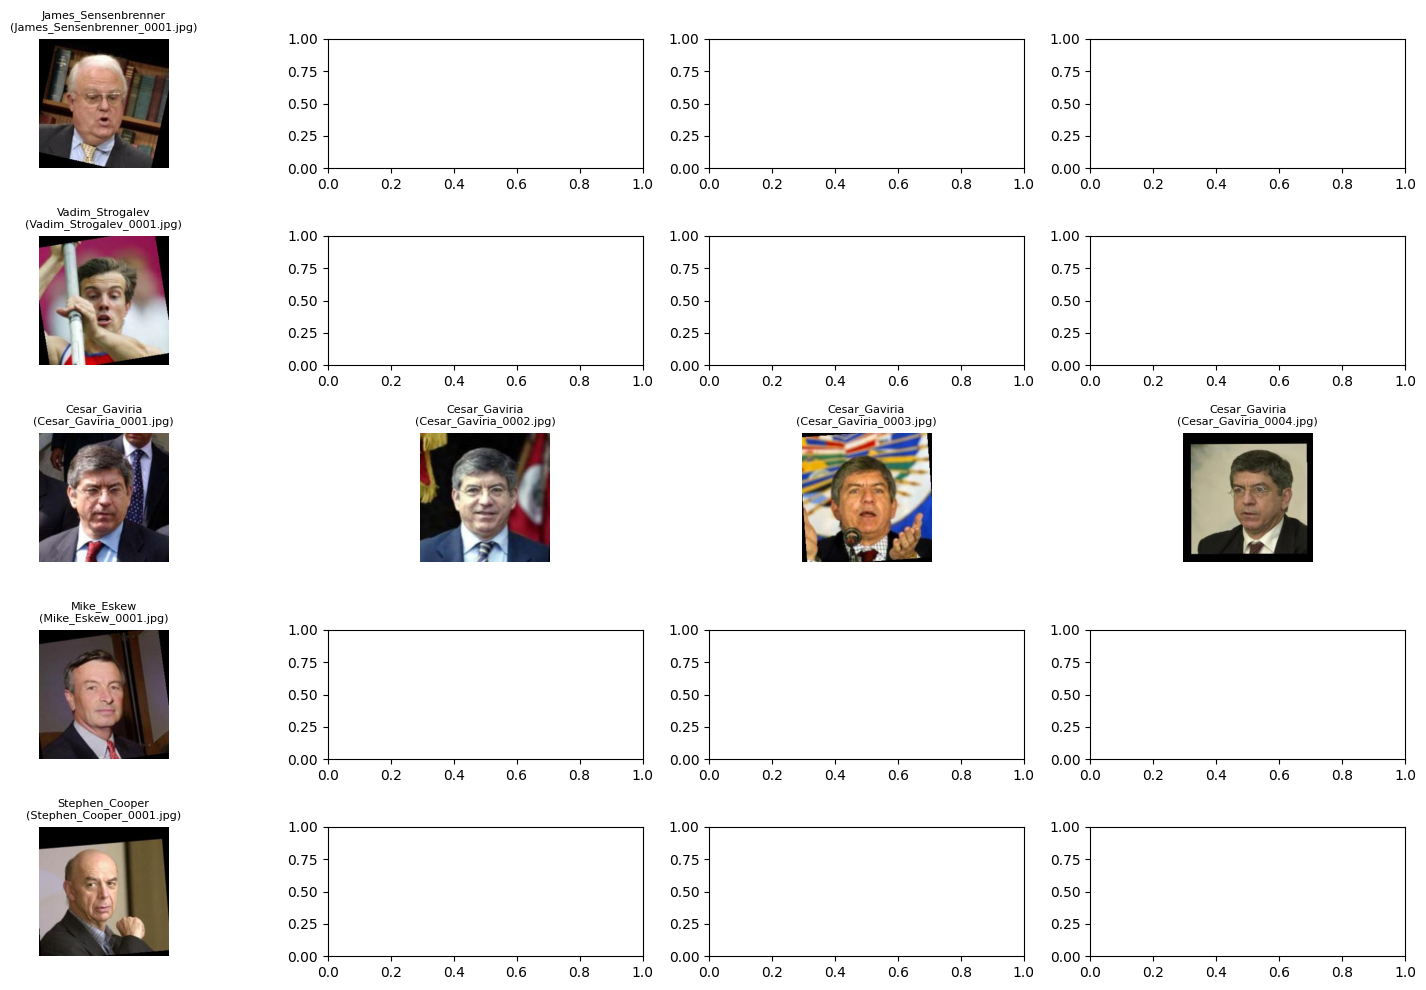

In [8]:
#show a few examples of the faces from diff ppl
sample_people = random.sample(person_dirs, min(5, len(person_dirs)))
fig,axes = plt.subplots(len(sample_people), 4, figsize=(15,10))
for i, person_dir in enumerate(sample_people):
    images = sorted([f for f in person_dir.iterdir() if f.suffix.lower() in image_extensions])
    for j in range(min(4, len(images))):
        img = Image.open(images[j])
        axes[i,j].imshow(img)
        axes[i,j].set_title(f"{person_dir.name}\n({images[j].name})", fontsize=8)
        axes[i,j].axis('off')
plt.tight_layout()
plt.show()



In [9]:
# Check image dimensions consistency
dimensions = []
for person_dir in random.sample(person_dirs, 50):
    for img_path in person_dir.glob("*.*"):
        if img_path.suffix.lower() in image_extensions:
            with Image.open(img_path) as img:
                dimensions.append(img.size)
widths, heights = zip(*dimensions)
print(f"Image dimensions (width × height): min {min(widths)}×{min(heights)}, max {max(widths)}×{max(heights)}")

Image dimensions (width × height): min 250×250, max 250×250


Siamese Dataset Class (with train/val split)

In [10]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from pathlib import Path
import random
from PIL import Image

class SiameseDataset(Dataset):
    """
    Dataset that generates pairs of face images and a similarity label.
    For each index, returns a positive (same person) or negative (different person) pair with 50% chance,
    ensuring that positive pairs consist of two different images of the same person.
    """
    def __init__(self,image_dir, person_to_images, transform=None, allowed_persons=None):
        """
        Args:
            image_dir (Path): root directory containing person subfolders.
            person_to_images (dict): mapping from person name to list of image paths.
            transform (callable, optional): image transforms.
            allowed_persons (set, optional): restrict to these persons (for train/val split).
        """
        self.image_dir = Path(image_dir)            #use Path to convert the image_dit string to a posixpath
        self.person_to_images = person_to_images    #so for each person image folder we want to get the image paths
        self.transform = transform                  #transformations to apply on the images
        self.allowed_persons = allowed_persons      #a restriction to what persons to include, this can be a folder of a person with a number of accepted images

        self.samples = []    #[0.(person1,(img1, img2,...)),1.(person2,(img1, img2,..)]
        for person, img_paths in person_to_images.items():
            if self.allowed_persons is not None and person not in self.allowed_persons:
                continue
            for img_path in img_paths:
                self.samples.append((person, str(img_path))) #append it as a tuple

        #build reverse mapping for faster lookup e.g {"person.name":".....jp",".....jpg"}
        self.person_to_images = {}
        for person, imag_paths in person_to_images.items():
            if self.allowed_persons is not None and person not in self.allowed_persons:
                continue
            self.person_to_images[person] = imag_paths
        #list of persons with at least 2 images (can for positive pair)
        self.persons_with_multi_images = [person for person, images in self.person_to_images.items() if len(images) >= 2] #this applies the restriction


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        person1, img1_path = self.samples[index]

        person_for_img2_path = person1 # Initialize with person1 for positive pairs

        #decide if this pair should be positive (same person) or begative (different)
        #if person1 has only one image, we cannot form a positive pair -> force negative

        if person1 in self.persons_with_multi_images and random.random() < 0.5:
            #positive pair
            img2_path=random.choice(self.person_to_images[person1])   #pick a random image of the same person in the folder
            #ensure different image/image path is selected for the same person
            attempts = 0
            while img2_path == img1_path and len(self.person_to_images[person1]) > 1:
                img2_path = random.choice(self.person_to_images[person1])
                attempts += 1
                if attempts > 10:
                    break
            label = 1.0              #label 1 for positive pairs of images
            # person_for_img2_path remains person1
        else:
            #negative pair
            person2 = random.choice([p for p in self.person_to_images.keys() if p != person1])
            img2_path = random.choice(self.person_to_images[person2])
            label = 0.0             #label 0 for negative pairs of images
            person_for_img2_path = person2 # Update for negative pair

        #load images
        img1 = Image.open(self.image_dir / person1 /img1_path).convert("RGB")
        img2 = Image.open(self.image_dir / person_for_img2_path /img2_path).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor([label], dtype=torch.float32)

In [ ]:
#prepare person -> images mapping from the entire dataset
all_person_to_images_dict = {}
for person_dir in person_dirs:
    images = [f.name for f in person_dir.iterdir() if f.suffix.lower() in image_extensions]
    if images:
        all_person_to_images_dict[person_dir.name] = images
    else:
        print(f"Warning: skipping empty person directory {person_dir}")
        continue

In [ ]:
list(all_person_to_images_dict.items())[:3]

In [ ]:
#split identities to train (80%) and validation (20%)
all_persons = list(all_person_to_images_dict.keys())
random.shuffle(all_persons)

split_idx = int(0.8 * len(all_persons))

train_persons = set(all_persons[:split_idx])
val_persons = set(all_persons[split_idx:])

print(f"train identities: {len(train_persons)}, val identities: {len(val_persons)}")

In [ ]:
##transforms to use
transform = transforms.Compose(
    [
        transforms.Resize((128,128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ]
)

In [ ]:
DATA_DIR

In [ ]:
##create dataset instances
train_dataset = SiameseDataset(lfw_root,
                               all_person_to_images_dict,
                               transform=transform,
                               allowed_persons=train_persons)


val_dataset = SiameseDataset(lfw_root,
                             all_person_to_images_dict,
                             transform=transform,
                             allowed_persons=val_persons)

In [ ]:
#batchoing and dataloading
from torch.utils.data import DataLoader

BATCH_SIZE = 4
num_workers = os.cpu_count()
print(f"num_workers: {num_workers}")


train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=num_workers,
                          pin_memory=False)

val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False,
                        num_workers=num_workers,
                        pin_memory=False)

In [ ]:
img1_batch, img2_batch, labels = next(iter(train_loader))
print("Batch shapes:", img1_batch.shape, img2_batch.shape, labels.shape)
print("Labels:", labels.squeeze())

Siamese Network Architecture

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict


#backbone
class EmbeddingNet(nn.Module):
    """
    CNN that maps a face image (3 × 128 × 128) to a 128-dimensional embedding vector.
    Designed for simplicity and fast prototyping; can be replaced with a pretrained backbone later.
    """
    def __init__(self, embedding_dim=128):
        super(EmbeddingNet, self).__init__()
        self.conv_layers = nn.Sequential(
            OrderedDict([
                #conv block 1
            ('conv1', nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2)),
            ('batch1', nn.BatchNorm2d(32)),
            ('relu1', nn.ReLU(inplace=True)),
                #conv block 2
            ('conv2', nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2)),
            ('batch2', nn.BatchNorm2d(64)),
            ('relu2', nn.ReLU(inplace=True)),
                #conv block 3
            ('conv3', nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=2)),
            ('batch3', nn.BatchNorm2d(128)),
            ('relu3', nn.ReLU(inplace=True)),
                #conv block 4
            ('conv4', nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=2)),
            ('batch4', nn.BatchNorm2d(256)),
            ('relu4', nn.ReLU(inplace=True)),

            ('adaptivepool', nn.AdaptiveAvgPool2d((1, 1))),
            #you can add more if you want a bigger network

            ]))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, embedding_dim), #no sigmoid because want embeddings, thats what the network will learn
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1) #L2 normalized embeddings

#siamese class for similarity
class SiameseNetwork(nn.Module):
    """
    Siamese network that takes two input images and produces their embeddings
    and the Euclidean distance between them.
    """
    def __init__(self, embedding_net):
        super(SiameseNetwork, self).__init__()
        self.embedding_net = embedding_net

    def forward(self, img1, img2):
        embedding1 = self.embedding_net(img1)
        embedding2 = self.embedding_net(img2)
        distance_between_embeddings = F.pairwise_distance(embedding1, embedding2, keepdim=True) #F.pairwise_distance is a function used to calculate the distance between two batches of vectors.
        return embedding1, embedding2, distance_between_embeddings

In [ ]:
##instantiate the class and test with dummy batch
embedding_net = EmbeddingNet() #since the class has a default embed dim initialized at 128 we don't have to call it
siamese_net = SiameseNetwork(embedding_net)

#test
dummy_img1 = torch.randn(4,3,128,128) #4xbatch of dummy images

dummy_img2 = torch.randn(4,3,128,128) #4xbatch of dummy images

embedding1, embedding2, distance = siamese_net(dummy_img1, dummy_img2)

In [ ]:
print("Embedding shapes:", embedding1.shape, embedding2.shape)
print("Distance:", distance)

In [ ]:
def get_model_info(model):
    """
    Calculates the number of trainable parameters and the estimated model size in MB.
    Args:
        model (torch.nn.Module): The PyTorch model.
    Returns:
        tuple: A tuple containing (num_parameters, model_size_mb).
    """
    num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Estimate model size by summing up the size of parameters (in bytes)
    # Assuming float32 (4 bytes per parameter)
    param_size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    model_size_mb = param_size_bytes / (1024**2)

    return num_parameters, model_size_mb

# Example usage with your siamese_net
num_params, model_size = get_model_info(siamese_net)
print(f"Total Trainable Parameters: {num_params:_}")
print(f"Estimated Model Size: {model_size:.2f} MB")


In [ ]:
!pip install torchsummary

In [ ]:
from torchsummary import summary
import torch

# The input size for the EmbeddingNet (3 channels, 128x128 pixels)
input_size = (3, 128, 128)

print("\nEmbedding Network Architecture Summary:")
summary(embedding_net, input_size=input_size)


Loss Functions (Contrastive & Triplet)

In [ ]:
import torch
import torch.nn as nn


class ContrastiveLoss(nn.Module):
    """
    Contrastive loss function.
    Takes embeddings of two samples and a target label == 1
    if samples are from the same class and label == 0 otherwise.
    Dimensionality Reduction by Learning an Invariant Mapping (Hadsell et al.)
    """
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, distance, label):
        """
        Args:
            distance: tensor of shape (batch,) – Euclidean distance between embeddings.
            label:    tensor of shape (batch,) – 1 for same person, 0 for different.
        """
        # For positive pairs (label=1): loss = 0.5 * distance^2
        # For negative pairs (label=0): loss = 0.5 * max(0, margin - distance)^2
        loss_pos = label * (distance ** 2)
        neg_loss = (1-label) * (torch.clamp(self.margin - distance, min=0) ** 2)
        loss = 0.5 * (loss_pos + neg_loss)
        return loss.mean()

class TripletLoss(nn.Module):
    """
    Triplet loss with online hard or semi-hard mining (basic implementation).
    Expects embeddings and labels for a batch.
    """
    def __init__(self, margin=1.0, mining_type='hard'):
        """
        Args:
            margin: desired gap between positive and negative distances.
            mining: 'hard', 'semi-hard', or 'all' (not implemented here, just simple placeholder)
        """
        super(TripletLoss, self).__init__()
        self.margin = margin
        self.mining_type = mining_type

    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: tensor of shape (batch, embedding_dim) – embeddings of the batch.
            labels:     tensor of shape (batch,) – labels of the batch
        Returns:
            triplet loss
        """

        distance_matrix = torch.cdist(embeddings, embeddings ,p=2)
        batch_size = embeddings.size(0)
        loss = 0.0
        count = 0

        for i in range(batch_size):
            pos_mask = (labels == labels[i]) & (torch.arange(batch_size) != i)
            neg_mask = labels != labels[i]

            if pos_mask.sum() == 0 or neg_mask.sum() == 0:
                continue
            pos_dist = distance_matrix[i][pos_mask].min() #hardest positive
            neg_dist = distance_matrix[i][neg_mask].min() #hardest negative

            #semi-hard  mining: negative should be harder than positive but not within margin
            if self.mining_type == "semi-hard":
                if neg_dist > pos_dist and (neg_dist - pos_dist) < self.margin:
                    loss += torch.clamp(pos_dist - neg_dist + self.margin, min=0.0)
                    count += 1
                #for hard mining: always use the hardest
            elif self.mining_type == "hard":
                loss += torch.clamp(pos_dist - neg_dist + self.margin, min=0.0)
                count += 1
        if count == 0:
            return torch.tensor(0.0, requires_grad=True)
        return loss/count

In [ ]:
# Quick test
dummy_embeddings = torch.tensor([[0.2, 0.3], [0.4, 0.1], [0.5, 0.5], [0.2, 0.4]], dtype=torch.float32)
dummy_labels = torch.tensor([0, 1, 1, 1])  # Person IDs
dummy_distance_euclidean = torch.norm(dummy_embeddings[0] - dummy_embeddings[1])

contrastive = ContrastiveLoss(margin=2.0)
triplet = TripletLoss(margin=1.0, mining_type='semi-hard')

print("Dummy distance:", dummy_distance_euclidean.item())
print("Contrastive loss (positive, label=1):", contrastive(dummy_distance_euclidean.unsqueeze(0), torch.tensor([0])))
print("Triplet loss:", triplet(dummy_embeddings, dummy_labels).item())

In [ ]:
dummy_embeddings[0]

Implements ContrastiveLoss that pulls same-identity pairs together (small distance) and pushes different-identity pairs apart beyond a margin.

Implements a simple TripletLoss with online hard or semi-hard mining (useful later if we want to compare performance or use a hybrid approach).

The quick test verifies the functions work as expected.

Training Loop with Validation and t-SNE Visualization

In [ ]:
import torch.optim as optim
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

DEVICE= torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

LEARNING_RATE = 1e-3

model = SiameseNetwork(EmbeddingNet(embedding_dim=128)).to(DEVICE)
criterion = ContrastiveLoss(margin=2.0).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=num_workers,
                          pin_memory=False)

val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False,
                        num_workers=num_workers,
                        pin_memory=False)

def compute_accuracy(model, dataloader, device, threshold=1.0):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for img1, img2, labels in dataloader:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
            _, _, distances = model(img1, img2)
            preds = (distances < threshold).float()
            correct += (preds == labels.squeeze()).sum().item()
            total += labels.size(0)
        return correct/total

def visualize_embeddings(model, dataset, device, num_persons=10, images_per_person=5, title=" "):
    """
    Sample a few persons, compute embeddings, reduce with t-SNE, and plot.
    """
    model.eval()

    #select random persons with enough images
    eligible_persons = [(p,imgs) for p, imgs in dataset.person_to_images.items() if len(imgs)>= images_per_person] #this will give us a few people because we want persons that have at least 5 images

    if len(eligible_persons) < num_persons:
        selected = eligible_persons
    else:
        #if too many persons fit the criteria of at least 5 images, lets select a 10 randomly
        selected = random.sample(eligible_persons, num_persons)

    embeddings = []

    labels = [] #person names

    with torch.no_grad():
        for person, img_paths in selected:
            chosen_imgs = random.sample(img_paths, images_per_person)
            for img_name in chosen_imgs:
                img = Image.open(dataset.image_dir / person / img_name).convert("RGB")
                img_tensor = dataset.transform(img).unsqueeze(0).to(device)
                emb = model.embedding_net(img_tensor).cpu().numpy()[0]
                embeddings.append(emb)
                labels.append(person)

    embeddings = np.array(embeddings)

    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30,len(embeddings)-1))

    emb2_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8,6))
    unique_labels = list(set(labels))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
    for i, label in enumerate(unique_labels):
        idx = [j for j, p in enumerate(labels) if p == person]
        plt.scatter(emb2_2d[idx, 0], emb2_2d[idx,1], c=[colors[i]], label=person, alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.title(f"tsne of valifdation embeddings: {title}")
    plt.tight_layout()
    plt.show()
    return embeddings


In [ ]:
embeddings = visualize_embeddings(model, val_dataset, DEVICE, num_persons=8, images_per_person=5)
embeddings.shape

T-distributed Stochastic Neighbor Embedding.

t-SNE [1] is a tool to visualize high-dimensional data. It converts
similarities between data points to joint probabilities and tries
to minimize the Kullback-Leibler divergence between the joint
probabilities of the low-dimensional embedding and the
high-dimensional data

Training Loop

In [ ]:
EPOCHS = 20
LOG_INTERVAL = 20

for epoch in range(1,EPOCHS+1):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch_idx, (img1, img2, labels) in enumerate(pbar):
        img1, img2, labels = img1.to(DEVICE), img2.to(DEVICE), labels.to(DEVICE).squeeze()
        optimizer.zero_grad()
        _, _, distances = model(img1, img2)
        loss = criterion(distances, labels) #contrastive loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (batch_idx + 1) % LOG_INTERVAL == 0:
            pbar.set_postfix({'loss': running_loss / LOG_INTERVAL})
            running_loss = 0.0

    #validation accuracy
    val_acc = compute_accuracy(model, val_loader, DEVICE,threshold=1.0)
    print(f"Epoch {epoch}/{EPOCHS}, val_acc: {val_acc:.3f}")

    #tsne every epoch (or every other)
    if epoch % 1 == 0:
        visualize_embeddings(model,
                             val_dataset,
                             DEVICE,
                             title=f"epoch {epoch}",
                             num_persons=8,
                             images_per_person=5)

print("training complete")


Moves model and loss to GPU if available.

Defines a simple verification accuracy function (distance < threshold -> same person). The threshold (1.0) can be tuned later.

Implements training loop with progress bars and periodic logging.

After each epoch, computes validation accuracy and visualises the embedding space with t-SNE for a subset of identities.

The t-SNE plot shows whether the model is learning to cluster same-identity faces together.

Evaluation: ROC, AUC, EER, and Best Threshold

In [ ]:
from sklearn.metrics import (roc_curve, auc,
                             roc_auc_score,
                             confusion_matrix,
                             accuracy_score)
import matplotlib.pyplot as plt
import numpy as np

def evaluate_verification(model, dataloader, device):
    """
    Run inference on all pairs in dataloader, collect distances and labels,
    compute ROC curve, AUC, best threshold (max accuracy), and EER.
    Returns a dict of metrics and plots.
    """
    model.eval()
    all_distances = []
    all_labels =[]
    with torch.no_grad():
        for img1, img2, labels in dataloader:
            img1, img2 = img1.to(device), img2.to(device)
            _,_, distances = model(img1, img2)
            all_distances.extend(distances.cpu().numpy())
            all_labels.extend(labels.squeeze().cpu().numpy())
    distances = np.array(all_distances)
    labels = np.array(all_labels)

    #roc_curve
    fpr, tpr, thresholds = roc_curve(labels, -distances) #neg distances:  smaller distance -> higher score
    roc_auc = auc(fpr, tpr)

    #finding best threshold
    best_acc = 0.0
    best_threshold = 0.0
    for threshold in np.linspace(distances.min(), distances.max(),200):
        preds = (distances < threshold).astype(int)
        acc = accuracy_score(labels, preds)
        if acc > best_acc:
            best_acc = acc
            best_threshold = threshold

    #equal error rate (eer): point where FPR = 1 - TPR (false negative rate)
    fnr  = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = fpr[eer_idx]

    #confusion matrix at best threshold
    preds_best_threshold = (distances < best_threshold).astype(int)
    cm = confusion_matrix(labels, preds_best_threshold)

    #plot roc
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
    plt.scatter(fpr[eer_idx], tpr[eer_idx], marker='o', color='red', label=f'EER point (threshold = {best_threshold:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.title('Receiver Operating Characteristic')
    plt.show()

    #plot distrution of distances for positive and negative pairs
    plt.subplot(1,2,2)
    pos_dist = distances[labels ==1]
    neg_dist = distances[labels ==0]
    plt.hist(pos_dist, bins=20, alpha=0.5, label='positive')
    plt.hist(neg_dist, bins=20, alpha=0.5, label='negative')
    plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'best threshold ({best_threshold:.2f})')
    plt.xlabel('Euclidean Distance')
    plt.ylabel('Count')
    plt.legend()
    plt.title('Distribution of distances for positive and negative pairs')
    plt.tight_layout()
    plt.show()

    metrics = {
        "roc_auc": roc_auc,
        "eer": eer,
        "best_threshold": best_threshold,
        "best_acc": best_acc,
        "cm": cm
    }
    print("Evaluation Metrics:")
    print(f"  AUC: {roc_auc:.4f}")
    print(f"  EER: {eer:.4f}")
    print(f"  Best threshold: {best_threshold:.4f} (acc: {best_acc:.4f})")
    print(f"  Confusion matrix:\n{cm}")

    return metrics

#running on the val set
metrics = evaluate_verification(model, val_loader, DEVICE)


Collects all Euclidean distances and corresponding pair labels from the validation DataLoader.

Computes the ROC curve and AUC – note we negate distances so that smaller distance (more similar) yields a higher score.

Finds the distance threshold that gives the best accuracy, and computes the Equal Error Rate (EER).

Plots the ROC curve with the EER point, and the histograms of distances for positive/negative pairs, with the best threshold marked.

Prints all metrics: AUC, EER, best threshold, accuracy, and confusion matrix.

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def visualize_predictions(model, dataloader, device, num_examples=5):
    """
    Display image pairs with true and predicted labels.
    - Green title  = correct prediction
    - Red title    = wrong prediction
    """
    model.eval()
    data_iter = iter(dataloader)
    img1, img2, labels = next(data_iter)
    img1, img2, labels = img1.to(device), img2.to(device), labels.to(device).squeeze()

    with torch.no_grad():
        _, _, distances = model(img1, img2)

    # Unnormalize images for display (reverse the mean/std we used)
    # We used mean=0.5, std=0.5 → pixel = img * 0.5 + 0.5
    def unnormalize(tensor):
        return tensor * 0.5 + 0.5

    fig, axes = plt.subplots(min(num_examples, len(labels)), 2, figsize=(6, 3 * min(num_examples, len(labels))))
    if min(num_examples, len(labels)) == 1:
        axes = axes.reshape(1, 2)  # make 2D for consistency

    for i in range(min(num_examples, len(labels))):
        true_label = labels[i].item()
        dist = distances[i].item()
        pred = 1 if dist < 1.0 else 0   # using the default threshold 1.0

        # Show face 1
        face1 = unnormalize(img1[i].cpu())
        axes[i, 0].imshow(face1.permute(1, 2, 0))
        axes[i, 0].set_title("Face 1")
        axes[i, 0].axis('off')

        # Show face 2
        face2 = unnormalize(img2[i].cpu())
        axes[i, 1].imshow(face2.permute(1, 2, 0))
        axes[i, 1].set_title("Face 2")
        axes[i, 1].axis('off')

        # Title above the pair
        true_text = "SAME" if true_label == 1 else "DIFFERENT"
        pred_text = "SAME" if pred == 1 else "DIFFERENT"
        color = 'green' if true_label == pred else 'red'
        fig.suptitle(f"True: {true_text} | Pred: {pred_text} | Dist: {dist:.3f}", color=color, fontsize=14)

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_predictions(model, val_loader, DEVICE, num_examples=1)